In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import seaborn as sns

In [ ]:
df = pd.read_csv("quick_commerce_data_modified_cleaned (1).csv")

In [12]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [13]:
df.columns

Index(['Order_ID', 'Company', 'City', 'Customer_Age', 'Order_Value',
       'Delivery_Time_Min', 'Distance_Km', 'Items_Count', 'Product_Category',
       'Payment_Method', 'Customer_Rating', 'Discount_Applied',
       'Delivery_Partner_Rating'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947752 entries, 0 to 947751
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  int64  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 94.0+ MB


In [15]:
df.shape


(947752, 13)

In [16]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912008,16.506620,7.750048,10.313292,3.042655,0.400786,3.800295
std,2.887273e+05,12.118982,374.175332,6.340851,4.187153,5.630770,1.202499,0.490058,0.718762
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.000000
25%,1.249939e+06,28.000000,288.000000,12.000000,4.100000,5.000000,2.000000,0.000000,3.000000
50%,1.500026e+06,38.000000,532.000000,16.000000,7.800000,10.000000,3.000000,0.000000,4.000000
75%,1.750145e+06,49.000000,797.000000,20.000000,11.400000,15.000000,4.000000,1.000000,4.000000
max,2.000000e+06,59.000000,2492.000000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [17]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

In [18]:
df.columns

Index(['order_id', 'company', 'city', 'customer_age', 'order_value',
       'delivery_time_min', 'distance_km', 'items_count', 'product_category',
       'payment_method', 'customer_rating', 'discount_applied',
       'delivery_partner_rating'],
      dtype='object')

In [19]:
df.isnull().sum()

order_id                   0
company                    0
city                       0
customer_age               0
order_value                0
delivery_time_min          0
distance_km                0
items_count                0
product_category           0
payment_method             0
customer_rating            0
discount_applied           0
delivery_partner_rating    0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.dtypes

order_id                     int64
company                     object
city                        object
customer_age                 int64
order_value                  int64
delivery_time_min            int64
distance_km                float64
items_count                  int64
product_category            object
payment_method              object
customer_rating              int64
discount_applied             int64
delivery_partner_rating      int64
dtype: object

In [23]:
df["order_value"] = pd.to_numeric(df["order_value"])
df["delivery_time_min"] = pd.to_numeric(df["delivery_time_min"])
df["distance_km"] = pd.to_numeric(df["distance_km"])

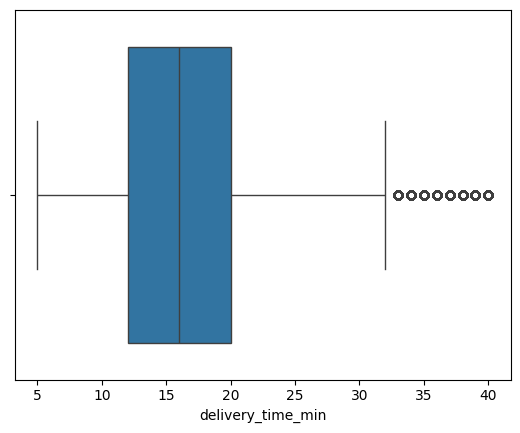

In [24]:
sns.boxplot(x=df["delivery_time_min"])
plt.show()

In [25]:
df = df[df["delivery_time_min"] < 120]

In [26]:
df = df[df["order_value"] > 0]
df = df[df["distance_km"] > 0]

In [27]:
df["delay_flag"] = df["delivery_time_min"].apply(
    lambda x: "Delayed" if x > 25 else "On Time"
)

In [31]:
print(df.columns)

Index(['order_id', 'company', 'city', 'customer_age', 'order_value',
       'delivery_time_min', 'distance_km', 'items_count', 'product_category',
       'payment_method', 'customer_rating', 'discount_applied',
       'delivery_partner_rating', 'delay_flag'],
      dtype='object')


In [32]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['order_id', 'company', 'city', 'customer_age', 'order_value',
       'delivery_time_min', 'distance_km', 'items_count', 'product_category',
       'payment_method', 'customer_rating', 'discount_applied',
       'delivery_partner_rating', 'delay_flag'],
      dtype='object')


In [33]:
df["order_size"] = df["items_count"].apply(
    lambda x: "Small" if x <= 3 else "Medium" if x <= 6 else "Large"
)

In [34]:
df["customer_segment"] = df["order_value"].apply(
    lambda x: "Low" if x < 300 else "Medium" if x < 700 else "High"
)

In [35]:
df["delivery_efficiency"] = (
    df["distance_km"] / df["delivery_time_min"]
)

In [36]:
df["discount_flag"] = df["discount_applied"].apply(
    lambda x: "Yes" if x > 0 else "No"
)

In [37]:
df.head()

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating,delay_flag,order_size,customer_segment,delivery_efficiency,discount_flag
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,On Time,Large,High,0.631579,Yes
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,On Time,Large,High,0.635000,No
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,On Time,Large,High,0.282353,No
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,On Time,Small,High,1.066667,Yes
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,On Time,Large,Medium,0.200000,No


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947752 entries, 0 to 947751
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 947752 non-null  int64  
 1   company                  947752 non-null  object 
 2   city                     947752 non-null  object 
 3   customer_age             947752 non-null  int64  
 4   order_value              947752 non-null  int64  
 5   delivery_time_min        947752 non-null  int64  
 6   distance_km              947752 non-null  float64
 7   items_count              947752 non-null  int64  
 8   product_category         947752 non-null  object 
 9   payment_method           947752 non-null  object 
 10  customer_rating          947752 non-null  int64  
 11  discount_applied         947752 non-null  int64  
 12  delivery_partner_rating  947752 non-null  int64  
 13  delay_flag               947752 non-null  object 
 14  orde

In [39]:
df.describe()

,order_id,customer_age,order_value,delivery_time_min,distance_km,items_count,customer_rating,discount_applied,delivery_partner_rating,delivery_efficiency
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912008,16.506620,7.750048,10.313292,3.042655,0.400786,3.800295,0.517145
std,2.887273e+05,12.118982,374.175332,6.340851,4.187153,5.630770,1.202499,0.490058,0.718762,0.349947
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.000000,0.016129
25%,1.249939e+06,28.000000,288.000000,12.000000,4.100000,5.000000,2.000000,0.000000,3.000000,0.283333
50%,1.500026e+06,38.000000,532.000000,16.000000,7.800000,10.000000,3.000000,0.000000,4.000000,0.468421
75%,1.750145e+06,49.000000,797.000000,20.000000,11.400000,15.000000,4.000000,1.000000,4.000000,0.654545
max,2.000000e+06,59.000000,2492.000000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000,3.000000


In [42]:
df.to_csv("quick_commerce_data_modified_cleaned (1).csv", index=False)

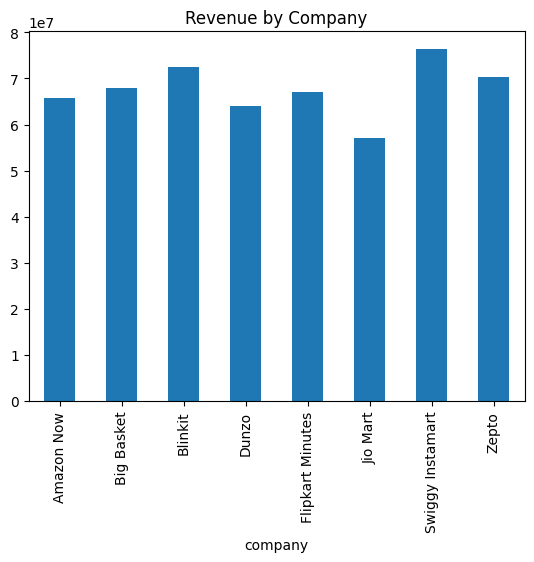

In [43]:
df.groupby("company")["order_value"].sum().plot(kind="bar")
plt.title("Revenue by Company")
plt.show()

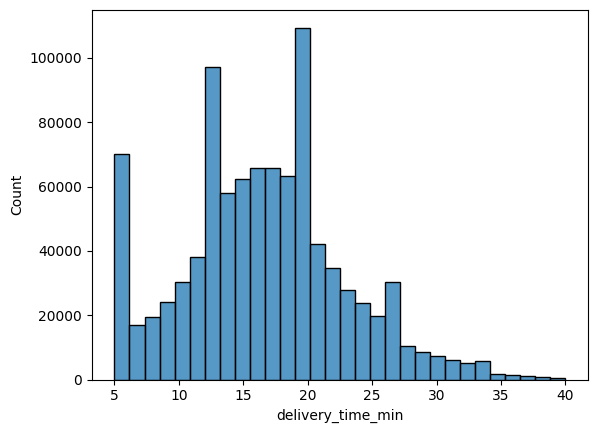

In [44]:
sns.histplot(df["delivery_time_min"], bins=30)
plt.show()

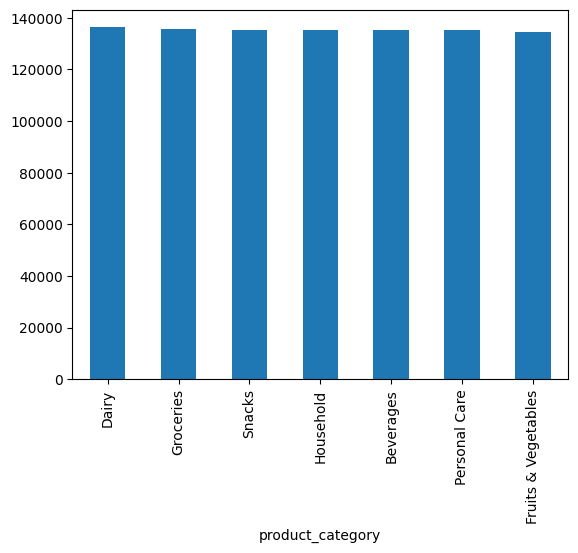

In [45]:
df["product_category"].value_counts().plot(kind="bar")
plt.show()

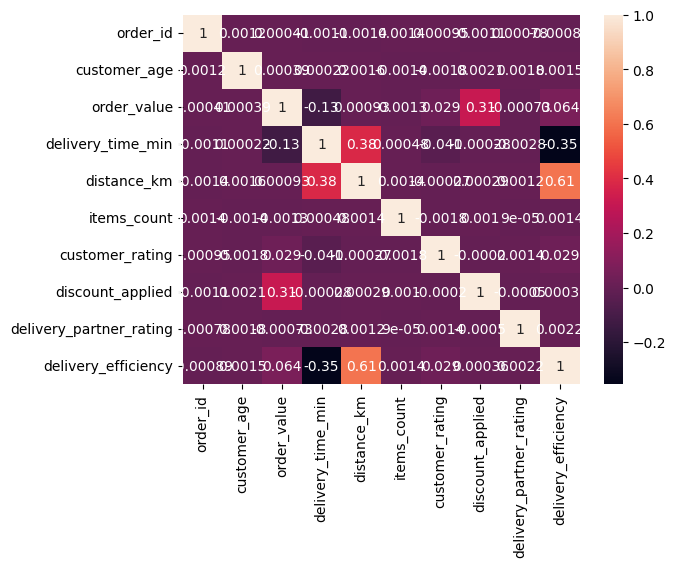

In [46]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()